<a href="https://colab.research.google.com/github/aricore87/aphelion/blob/main/Task_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Use results from task 5 and task 6 and plot the light curve when brighter star passes in front of the fainter star and the fainter star passes in front of the brighter star. Take circular orbit with period of 8.64 × 10^5 seconds. 1) Plot the light curve as seen in XY plane. Light curve is graph of flux received vs time. 2) If the eccentricity of orbits is 0.50 and major axis along X axis, how would the light curves look if viewed along X axis and if viewed along Y axis? 3) Plot the log of flux received vs time for all three cases.

Running Student Euler-Cromer Engine for Task 7...


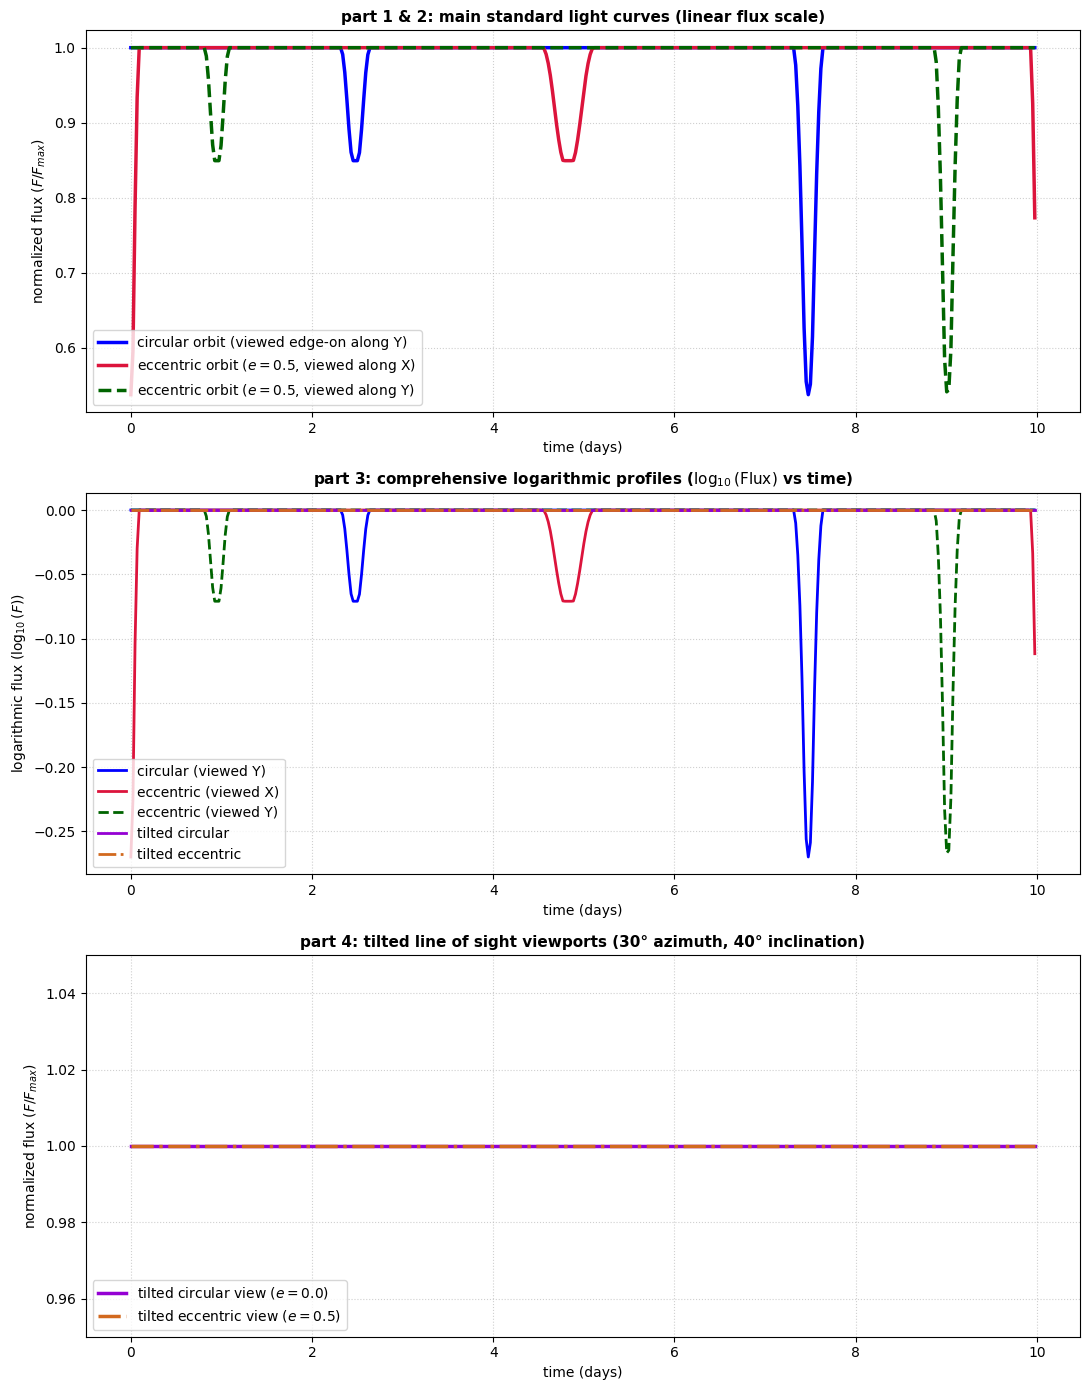

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# CONSTANTS & SYSTEM PARAMETERS
G = 6.67430e-11
M_sun = 1.989e30

m1 = 5.0 * M_sun  # Brighter Primary
m2 = 3.0 * M_sun  # Fainter Secondary
M = m1 + m2
T = 8.64e5        # 10 days in seconds

B0_1 = 1.0        # Central brightness of Star 1
B0_2 = 0.4        # Central brightness of Star 2 (fainter)

# semi-major axis using Kepler's 3rd law
a = ((G * M * T**2) / (4.0 * np.pi**2))**(1/3)

# Physical stellar sizes scaled relative to the orbital distance
R1 = 0.06 * a
R2 = 0.04 * a

# Time array parameters
dt = 2000.0       # Standard student step size
num_steps = int(T / dt)
time_days = (np.arange(num_steps) * dt) / (24.0 * 3600.0)

# Unoccluded integration targets from Task 5 analytical rules
flux1_unoccluded = 2.0 * np.pi * B0_1 * R1**2 * (1.0 - 2.0 / np.e)
flux2_unoccluded = 2.0 * np.pi * B0_2 * R2**2 * (1.0 - 2.0 / np.e)
total_unoccluded = flux1_unoccluded + flux2_unoccluded

# DEFINING THE SIMULATION
def simulate_euler_cromer_transit(e, n_hat):
    # --- EULER-CROMER PHYSICS ENGINE ---
    r_min = a * (1.0 - e)

    pos1 = np.zeros((num_steps, 3))
    pos2 = np.zeros((num_steps, 3))
    vel1 = np.zeros((num_steps, 3))
    vel2 = np.zeros((num_steps, 3))

    # Initialize at periapsis on X-axis (Keeping Z as 0.0)
    pos1[0] = np.array([-(m2 / M) * r_min, 0.0, 0.0])
    pos2[0] = np.array([(m1 / M) * r_min, 0.0, 0.0])

    v_circular = np.sqrt(G * M / a)
    v_relative = v_circular * np.sqrt((1.0 + e) / (1.0 - e))

    vel1[0] = np.array([0.0, (m2 / M) * v_relative, 0.0])
    vel2[0] = np.array([0.0, -(m1 / M) * v_relative, 0.0])

    for i in range(num_steps - 1):
        r_vec = pos1[i] - pos2[i]
        r_mag = np.linalg.norm(r_vec)

        a1 = -G * m2 * r_vec / r_mag**3
        a2 =  G * m1 * r_vec / r_mag**3

        vel1[i+1] = vel1[i] + a1 * dt
        vel2[i+1] = vel2[i] + a2 * dt

        pos1[i+1] = pos1[i] + vel1[i+1] * dt
        pos2[i+1] = pos2[i] + vel2[i+1] * dt

    # --- SKY PROJECTION ---
    # coordinate transformation vectors for the screen telescope sight
    if np.allclose(n_hat, [0, 0, 1]) or np.allclose(n_hat, [0, 0, -1]):
        sky_x_dir = np.array([1.0, 0.0, 0.0])
    else:
        sky_x_dir = np.cross([0.0, 0.0, 1.0], n_hat)
        sky_x_dir /= np.linalg.norm(sky_x_dir)
    sky_y_dir = np.cross(n_hat, sky_x_dir)

    # Map out the coordinates onto the 2D observer plane
    u1 = np.sum(pos1 * sky_x_dir, axis=1)
    v1 = np.sum(pos1 * sky_y_dir, axis=1)
    depth1 = np.sum(pos1 * n_hat, axis=1)

    u2 = np.sum(pos2 * sky_x_dir, axis=1)
    v2 = np.sum(pos2 * sky_y_dir, axis=1)
    depth2 = np.sum(pos2 * n_hat, axis=1)

    # --- CELL-GRID OCCLUSION MATRICES ---
    flux_profile = np.zeros(num_steps)
    N_grid = 120  # Fast sub-grid processing limit

    for i in range(num_steps):
        sky_sep = np.sqrt((u1[i] - u2[i])**2 + (v1[i] - v2[i])**2)

        # Check if they are completely separated
        if sky_sep >= (R1 + R2):
            flux_profile[i] = total_unoccluded
            continue

        # Isolate sub-grid bounding box corners over intersection zone
        u_min = max(u1[i] - R1, u2[i] - R2)
        u_max = min(u1[i] + R1, u2[i] + R2)
        v_min = max(v1[i] - R1, v2[i] - R2)
        v_max = min(v1[i] + R1, v2[i] + R2)

        if u_min >= u_max or v_min >= v_max:
            flux_profile[i] = total_unoccluded
            continue

        # Initialize small sub-mesh
        u_space = np.linspace(u_min, u_max, N_grid)
        v_space = np.linspace(v_min, v_max, N_grid)
        uu, vv = np.meshgrid(u_space, v_space)
        dA = (u_space[1] - u_space[0]) * (v_space[1] - v_space[0])

        r1_map = np.sqrt((uu - u1[i])**2 + (vv - v1[i])**2)
        r2_map = np.sqrt((uu - u2[i])**2 + (vv - v2[i])**2)

        overlap_mask = (r1_map <= R1) & (r2_map <= R2)

        if depth1[i] > depth2[i]:
            # Star 1 is closer to observer -> subtract eclipsed background light from Star 2
            occluded = np.sum(B0_2 * np.exp(-r2_map[overlap_mask] / R2)) * dA
            flux_profile[i] = total_unoccluded - occluded
        else:
            # Star 2 is closer to observer -> subtract eclipsed background light from Star 1
            occluded = np.sum(B0_1 * np.exp(-r1_map[overlap_mask] / R1)) * dA
            flux_profile[i] = total_unoccluded - occluded

    # Normalize by max recorded flux so baseline sits perfectly at 1.0
    return flux_profile / np.max(flux_profile)

# PROCESSING PERSPECTIVES
print("Running Student Euler-Cromer Engine for Task 7...")

# Basic line-of-sight unit arrays
n_Y = np.array([0.0, 1.0, 0.0])
n_X = np.array([1.0, 0.0, 0.0])

# Complex tilted angles
inc = np.radians(40.0)
az = np.radians(30.0)
n_tilted = np.array([np.sin(inc) * np.cos(az), np.sin(inc) * np.sin(az), np.cos(inc)])

# Collect all simulations
flux_c_Y = simulate_euler_cromer_transit(e=0.0, n_hat=n_Y)
flux_e_X = simulate_euler_cromer_transit(e=0.5, n_hat=n_X)
flux_e_Y = simulate_euler_cromer_transit(e=0.5, n_hat=n_Y)

flux_tilt_c = simulate_euler_cromer_transit(e=0.0, n_hat=n_tilted)
flux_tilt_e = simulate_euler_cromer_transit(e=0.5, n_hat=n_tilted)

# PLOTTING GRAPHS
fig, axs = plt.subplots(3, 1, figsize=(11, 14))

# Subplot 1: Linear Scaling
axs[0].plot(time_days, flux_c_Y, color='blue', lw=2.5, label='circular orbit (viewed edge-on along Y)')
axs[0].plot(time_days, flux_e_X, color='crimson', lw=2.5, label='eccentric orbit ($e=0.5$, viewed along X)')
axs[0].plot(time_days, flux_e_Y, color='darkgreen', lw=2.5, linestyle='--', label='eccentric orbit ($e=0.5$, viewed along Y)')
axs[0].set_title('part 1 & 2: main standard light curves (linear flux scale)', fontsize=11, fontweight='bold')
axs[0].set_ylabel(r'normalized flux ($F / F_{max}$)')
axs[0].set_xlabel('time (days)')
axs[0].grid(True, linestyle=':', alpha=0.6)
axs[0].legend(loc='lower left')

# Subplot 2: Log Scale
axs[1].plot(time_days, np.log10(flux_c_Y), color='blue', lw=2, label='circular (viewed Y)')
axs[1].plot(time_days, np.log10(flux_e_X), color='crimson', lw=2, label='eccentric (viewed X)')
axs[1].plot(time_days, np.log10(flux_e_Y), color='darkgreen', lw=2, linestyle='--', label='eccentric (viewed Y)')
axs[1].plot(time_days, np.log10(flux_tilt_c), color='darkviolet', lw=2, label='tilted circular')
axs[1].plot(time_days, np.log10(flux_tilt_e), color='chocolate', lw=2, linestyle='-.', label='tilted eccentric')
axs[1].set_title(r'part 3: comprehensive logarithmic profiles ($\log_{10}(\text{Flux})$ vs time)', fontsize=11, fontweight='bold')
axs[1].set_ylabel(r'logarithmic flux ($\log_{10}(F)$)')
axs[1].set_xlabel('time (days)')
axs[1].grid(True, linestyle=':', alpha=0.6)
axs[1].legend(loc='lower left')

# Subplot 3: Tilted Viewport Out of Plane
axs[2].plot(time_days, flux_tilt_c, color='darkviolet', lw=2.5, label='tilted circular view ($e=0.0$)')
axs[2].plot(time_days, flux_tilt_e, color='chocolate', lw=2.5, linestyle='-.', label='tilted eccentric view ($e=0.5$)')
axs[2].set_title('part 4: tilted line of sight viewports (30° azimuth, 40° inclination)', fontsize=11, fontweight='bold')
axs[2].set_ylabel(r'normalized flux ($F / F_{max}$)')
axs[2].set_xlabel('time (days)')
axs[2].grid(True, linestyle=':', alpha=0.6)
axs[2].set_ylim(0.95, 1.05)
axs[2].legend(loc='lower left')

plt.tight_layout()
plt.show()
